<a href="https://colab.research.google.com/github/JithmaKaluarachchi/RP-Project-Crash-Severity/blob/main/RP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Google Drive to access datasets
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Extract zip folders
import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/Colab Notebooks/Research Project/US_Accidents_March23.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('train')

In [3]:
# Install (one time)
!pip install -q imbalanced-learn xgboost lightgbm

In [4]:
# Imports
import os
import pandas as pd
import numpy as np
from IPython.display import display

In [5]:
# ML imports
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

In [6]:
# imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

In [7]:
# (2) Set data path and simple config
DATA_PATH = '/content/train/US_Accidents_March23.csv'   # <-- change if different
TARGET = 'Severity'                                    # <-- change if different

# If your CSV is very large and you want to develop on a subset first, set SAMPLE_NROWS to a positive int
SAMPLE_NROWS = None   # e.g., 200000 to read first 200k rows for development; None to read full file

print("DATA_PATH:", DATA_PATH)
print("TARGET:", TARGET)
print("SAMPLE_NROWS:", SAMPLE_NROWS)

DATA_PATH: /content/train/US_Accidents_March23.csv
TARGET: Severity
SAMPLE_NROWS: None


In [8]:
def robust_read_csv(path, nrows=None):
    # Try default read
    try:
        df = pd.read_csv(path, nrows=nrows)
        print("Read CSV using default read_csv(). Shape:", df.shape)
        return df
    except Exception as e:
        print("Default read_csv failed:", e)

    # Try python engine
    try:
        df = pd.read_csv(path, engine='python', low_memory=False, nrows=nrows)
        print("Read CSV with engine='python'. Shape:", df.shape)
        return df
    except Exception as e2:
        print("engine='python' failed:", e2)

    # Try latin1 encoding
    try:
        df = pd.read_csv(path, encoding='latin1', nrows=nrows)
        print("Read CSV with encoding='latin1'. Shape:", df.shape)
        return df
    except Exception as e3:
        print("latin1 read failed:", e3)

    # Try delimiter sniffing
    try:
        import csv
        with open(path, "r", encoding='utf-8', errors='ignore') as f:
            sample = f.read(8192)
        dialect = csv.Sniffer().sniff(sample)
        delim = dialect.delimiter

        df = pd.read_csv(path, sep=delim, engine='python', nrows=nrows)
        print(f"Read CSV with sniffed delimiter '{delim}'. Shape:", df.shape)
        return df
    except Exception as e4:
        print("Delimiter sniffing failed:", e4)
        traceback.print_exc()

    raise RuntimeError("All CSV read attempts failed. Check file format.")

In [13]:
DATA_PATH = '/content/train/US_Accidents_March23.csv'  # correct path after extraction
SAMPLE_NROWS = 1000  # or None for full file

# Check if file exists
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"File not found: {DATA_PATH}")

# Load CSV
df = robust_read_csv(DATA_PATH, nrows=SAMPLE_NROWS)
print(df.head())


Read CSV using default read_csv(). Shape: (1000, 46)
    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   
2  39.063148 -84.032608      NaN      NaN          0.01  ...      False   
3  39.747753 -84.205582      NaN      NaN          0.01  ...      False   
4  39.627781 -84.188354      NaN      NaN          0.01  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_

In [14]:
print("\nColumns:\n", df.columns.tolist())
print("\nRows, Cols:", df.shape)

# Check target column
if "Severity" not in df.columns:
    raise ValueError("❌ Column 'Severity' not found in dataset!")

print("\nSeverity distribution:")
print(df["Severity"].value_counts())

print("\nMissing values (top 20):")
print(df.isna().sum().sort_values(ascending=False).head(20))



Columns:
 ['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']

Rows, Cols: (1000, 46)

Severity distribution:
Severity
2    624
3    372
1      3
4      1
Name: count, dtype: int64

Missing values (top 20):
End_Lng              1000
End_Lat              1000
Precipitation(in)     813
Wind_Chill(F)         540
Wind_Speed(mph)        47
Visibility(mi)          3
Weather_Condition       2
Wind_Directi

In [15]:
# Identify feature columns (exclude target)
FEATURES = [c for c in df.columns if c != TARGET]

# Separate numeric and categorical columns
numeric_features = df[FEATURES].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df[FEATURES].select_dtypes(include=['object', 'bool']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


Numeric features: ['Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']
Categorical features: ['ID', 'Source', 'Start_Time', 'End_Time', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Wind_Direction', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


In [17]:
# Filter out classes with less than 2 samples
counts = df[TARGET].value_counts()
valid_classes = counts[counts >= 2].index
df_filtered = df[df[TARGET].isin(valid_classes)]

X = df_filtered[FEATURES]
y = df_filtered[TARGET]

# Optional: compute class weights for balanced training
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
class_weights_dict = dict(zip(np.unique(y), class_weights))
print("Class weights:", class_weights_dict)

# Stratified Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class distribution:\n", y_train.value_counts())
print("Test class distribution:\n", y_test.value_counts())


Class weights: {np.int64(1): np.float64(111.0), np.int64(2): np.float64(0.5336538461538461), np.int64(3): np.float64(0.8951612903225806)}
Train shape: (799, 45) Test shape: (200, 45)
Train class distribution:
 Severity
2    499
3    298
1      2
Name: count, dtype: int64
Test class distribution:
 Severity
2    125
3     74
1      1
Name: count, dtype: int64


In [19]:
from imblearn.over_sampling import SMOTE

# Safe SMOTE for very small classes
smote = SMOTE(random_state=42, k_neighbors=1)

rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        class_weight='balanced'  # optional
    ))
])

# Train
rf_pipeline.fit(X_train, y_train)

# Predictions
y_pred = rf_pipeline.predict(X_test)

# Evaluation
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['End_Lat' 'End_Lng']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['End_Lat' 'End_Lng']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Random Forest Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.83      0.87      0.85       125
           3       0.76      0.70      0.73        74

    accuracy                           0.81       200
   macro avg       0.53      0.52      0.53       200
weighted avg       0.80      0.81      0.80       200

Confusion Matrix:
[[  0   1   0]
 [  0 109  16]
 [  0  22  52]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
label_mapping = {label: idx for idx, label in enumerate(sorted(y_train.unique()))}
y_train_mapped = y_train.map(label_mapping)
y_test_mapped = y_test.map(label_mapping)

print("Label mapping:", label_mapping)


Label mapping: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2}


In [26]:
import xgboost as xgb
from sklearn.pipeline import Pipeline

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        objective='multi:softmax',  # multiclass
        eval_metric='mlogloss',
        use_label_encoder=False,
        n_estimators=200,
        random_state=42
    ))
])

# Train
xgb_pipeline.fit(X_train, y_train_mapped)

# Predictions
y_pred_xgb = xgb_pipeline.predict(X_test)

# Map predictions back to original labels
inverse_label_mapping = {v: k for k, v in label_mapping.items()}
y_pred_xgb_original = pd.Series(y_pred_xgb).map(inverse_label_mapping)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['End_Lat' 'End_Lng']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:31:35] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['End_Lat' 'End_Lng']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [27]:
from sklearn.metrics import classification_report, confusion_matrix

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb_original))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_original))

XGBoost Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.81      0.83      0.82       125
           3       0.71      0.69      0.70        74

    accuracy                           0.78       200
   macro avg       0.51      0.51      0.51       200
weighted avg       0.77      0.78      0.77       200

Confusion Matrix:
[[  0   1   0]
 [  0 104  21]
 [  0  23  51]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
print("Unique Severity levels:", df[TARGET].unique())
print("Severity distribution:\n", df[TARGET].value_counts())

Unique Severity levels: [3 2 1 4]
Severity distribution:
 Severity
2    624
3    372
1      3
4      1
Name: count, dtype: int64


In [29]:
# Example mapping
severity_mapping = {
    1: 'Low',
    2: 'Medium',
    3: 'High'
}

# Apply mapping
df['Severity_Label'] = df[TARGET].map(severity_mapping)

# Check result
print(df[['Severity', 'Severity_Label']].head(10))


   Severity Severity_Label
0         3           High
1         2         Medium
2         2         Medium
3         3           High
4         2         Medium
5         3           High
6         2         Medium
7         3           High
8         2         Medium
9         3           High


Severity level counts:
Severity_Label
Medium    624
High      372
Low         3
Name: count, dtype: int64


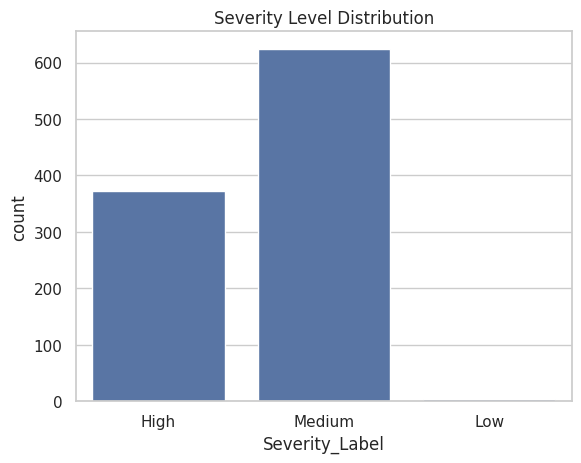

In [30]:
print("Severity level counts:")
print(df['Severity_Label'].value_counts())

# Visualize
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Severity_Label', data=df)
plt.title("Severity Level Distribution")
plt.show()
